In [1]:
#File Uploads

from google.colab import files
print("Upload CrSb.bands.up.gnu and CrSb.bands.dn.gnu")
uploaded = files.upload()

Upload CrSb.bands.up.gnu and CrSb.bands.dn.gnu


Saving CrSb.bands.dn.gnu to CrSb.bands.dn.gnu
Saving CrSb.bands.up.gnu to CrSb.bands.up.gnu


In [2]:
#Config

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as ticker

plt.rcParams.update({
    'font.size': 18,
    'axes.linewidth': 1.5,
    'axes.labelsize': 18,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    'legend.fontsize': 14,
})

FERMI   = 10.5605
ELIM    = [-1.5, 1]
DPI     = 600
FIGSIZE = (6, 6)

BAND_BLUE  = '#007acc'
GRID_GRAY  = '#808080'
UP_COLOR   = '#CC0000'
DN_COLOR   = '#007acc'
UP_ARROW   = '#8B0000'
DN_ARROW   = '#004c80'

if os.path.exists("CrSb.bands.up.gnu"):
    BANDS_UP_GNU = "CrSb.bands.up.gnu"
    BANDS_DN_GNU = "CrSb.bands.dn.gnu"
elif os.path.exists("CrSb_bands_up.gnu"):
    BANDS_UP_GNU = "CrSb_bands_up.gnu"
    BANDS_DN_GNU = "CrSb_bands_dn.gnu"
else:
    raise FileNotFoundError(
        "Expected CrSb.bands.up.gnu / CrSb.bands.dn.gnu or underscore variants")
print(f"Using: {BANDS_UP_GNU}, {BANDS_DN_GNU}")

K_GAMMA_IDX = 150
K_LABELS = [r'L$_1$', r'$\Gamma$', r'L$_2$']

Using: CrSb.bands.up.gnu, CrSb.bands.dn.gnu


In [3]:
#Parsing Data

def parse_gnu(fname):
    bands, cur = [], []
    with open(fname) as f:
        for line in f:
            s = line.strip()
            if s == '':
                if cur:
                    bands.append(np.array(cur))
                    cur = []
            else:
                v = s.split()
                cur.append([float(v[0]), float(v[1])])
    if cur:
        bands.append(np.array(cur))
    return bands

def get_vis(bands, fermi, elim):
    out = []
    for b in bands:
        e = b[:, 1] - fermi
        if e.max() > elim[0] and e.min() < elim[1]:
            out.append((b[:, 0], e))
    return out

bands_up = parse_gnu(BANDS_UP_GNU)
bands_dn = parse_gnu(BANDS_DN_GNU)
k = bands_up[0][:, 0]
k_gamma = k[K_GAMMA_IDX]
k_max = k[-1]
vis_up = get_vis(bands_up, FERMI, ELIM)
vis_dn = get_vis(bands_dn, FERMI, ELIM)

print(f"Total bands: {len(bands_up)} up, {len(bands_dn)} dn")
print(f"Visible bands: {len(vis_up)} up, {len(vis_dn)} dn")
print(f"K range: [{k[0]:.4f}, {k_max:.4f}], Γ at {k_gamma:.4f}")

Total bands: 23 up, 23 dn
Visible bands: 5 up, 5 dn
K range: [0.0000, 1.3411], Γ at 0.6706


In [4]:
#Helpers

def place_arrows(ax, kv, ev, direction='up', color='#8B0000', n=5):
    npts = len(kv)
    indices = np.linspace(npts * 0.12, npts * 0.88, n, dtype=int)
    al = 0.065
    for idx in indices:
        ek, ey = kv[idx], ev[idx]
        if ELIM[0] + 0.18 < ey < ELIM[1] - 0.18:
            if direction == 'up':
                head, tail = (ek, ey + al), (ek, ey - al)
            else:
                head, tail = (ek, ey - al), (ek, ey + al)
            ax.annotate('', xy=head, xytext=tail,
                arrowprops=dict(
                    arrowstyle='->,head_width=0.3,head_length=0.18',
                    color=color, lw=1.4, shrinkA=0, shrinkB=0),
                zorder=6)

def mcu_ax(ax):
    ax.axhline(0, color=GRID_GRAY, lw=0.8, ls='--', zorder=1)
    ax.axvline(k[0],    color=GRID_GRAY, lw=0.8, zorder=1)
    ax.axvline(k_gamma, color=GRID_GRAY, lw=0.8, zorder=1)
    ax.axvline(k_max,   color=GRID_GRAY, lw=0.8, zorder=1)
    ax.set_xlim(k[0], k_max)
    ax.set_ylim(ELIM)
    ax.set_ylabel(r'$E - E_{\mathrm{F}}$ (eV)')
    ax.set_xlabel('')
    ax.set_xticks([k[0], k_gamma, k_max])
    ax.set_xticklabels(K_LABELS)
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.tick_params(which='minor', length=3, width=0.8, direction='in',
                   top=True, right=True)

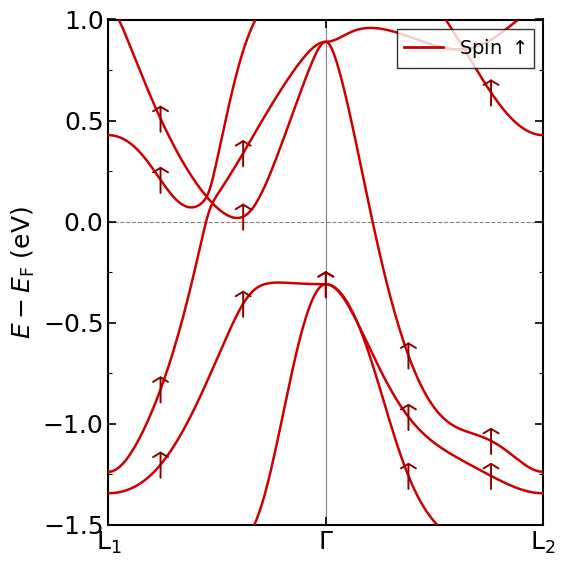

In [5]:
#Spin-Up with Arrows

fig1, ax1 = plt.subplots(figsize=FIGSIZE)
for kv, ev in vis_up:
    ax1.plot(kv, ev, color=UP_COLOR, lw=1.8, zorder=3)
    place_arrows(ax1, kv, ev, 'up', UP_ARROW, n=5)
mcu_ax(ax1)
h = mlines.Line2D([], [], color=UP_COLOR, lw=2, label=r'Spin $\uparrow$')
ax1.legend(handles=[h], loc='upper right')
fig1.tight_layout()
fig1.savefig('CrSb_spin_up_mcu.png', dpi=DPI, bbox_inches='tight')
plt.show()

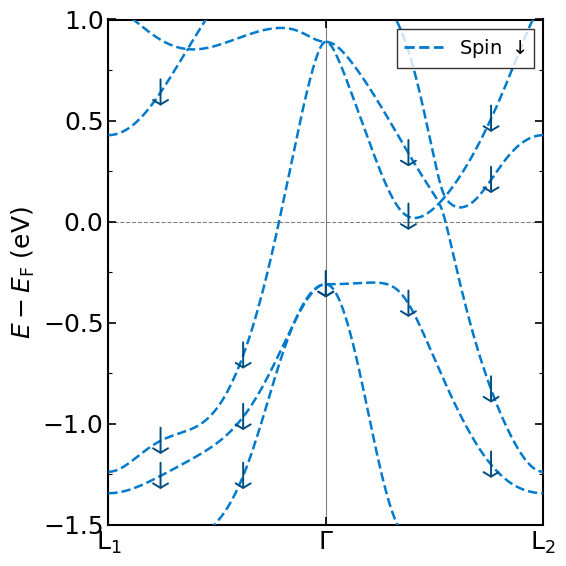

In [6]:
#Spin-Down with Arrows

fig2, ax2 = plt.subplots(figsize=FIGSIZE)
for kv, ev in vis_dn:
    ax2.plot(kv, ev, color=DN_COLOR, lw=1.8, ls='--', zorder=3)
    place_arrows(ax2, kv, ev, 'down', DN_ARROW, n=5)
mcu_ax(ax2)
h = mlines.Line2D([], [], color=DN_COLOR, lw=2, ls='--', label=r'Spin $\downarrow$')
ax2.legend(handles=[h], loc='upper right')
fig2.tight_layout()
fig2.savefig('CrSb_spin_dn_mcu.png', dpi=DPI, bbox_inches='tight')
plt.show()

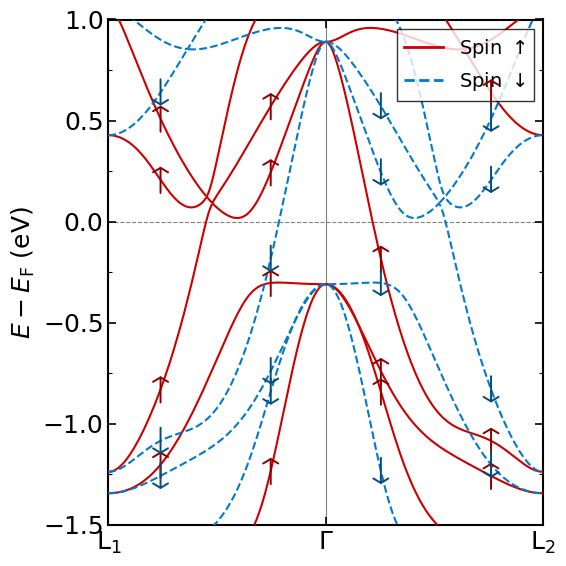

In [7]:
#Combined with Arrows

fig3, ax3 = plt.subplots(figsize=FIGSIZE)
for kv, ev in vis_up:
    ax3.plot(kv, ev, color=UP_COLOR, lw=1.5, zorder=3)
    place_arrows(ax3, kv, ev, 'up', UP_ARROW, n=4)
for kv, ev in vis_dn:
    ax3.plot(kv, ev, color=DN_COLOR, lw=1.5, ls='--', zorder=3)
    place_arrows(ax3, kv, ev, 'down', DN_ARROW, n=4)
mcu_ax(ax3)
h_up = mlines.Line2D([], [], color=UP_COLOR, lw=2, label=r'Spin $\uparrow$')
h_dn = mlines.Line2D([], [], color=DN_COLOR, lw=2, ls='--', label=r'Spin $\downarrow$')
ax3.legend(handles=[h_up, h_dn], loc='upper right')
fig3.tight_layout()
fig3.savefig('CrSb_combined_mcu.png', dpi=DPI, bbox_inches='tight')
plt.show()

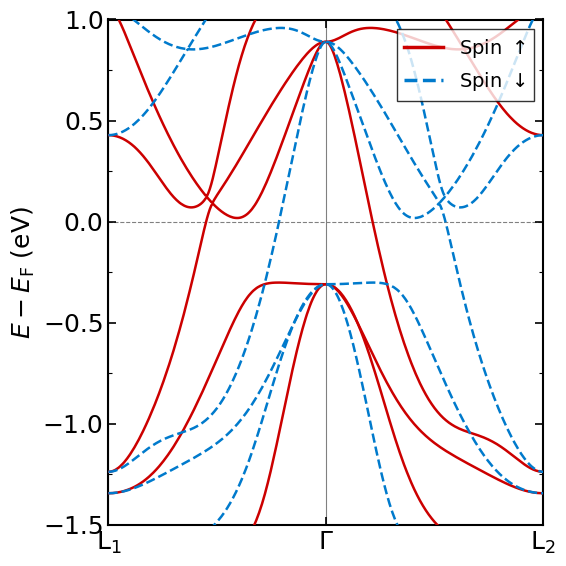

In [9]:
#Combined (Solid vs dashed)

fig4, ax4 = plt.subplots(figsize=FIGSIZE)
for kv, ev in vis_up:
    ax4.plot(kv, ev, color=UP_COLOR, lw=1.8, solid_capstyle='round', zorder=3)
for kv, ev in vis_dn:
    ax4.plot(kv, ev, color=DN_COLOR, lw=1.8, ls='--', solid_capstyle='round', zorder=3)
mcu_ax(ax4)
h_up = mlines.Line2D([], [], color=UP_COLOR, lw=2.5, label=r'Spin $\uparrow$')
h_dn = mlines.Line2D([], [], color=DN_COLOR, lw=2.5, ls='--', label=r'Spin $\downarrow$')
ax4.legend(handles=[h_up, h_dn], loc='upper right')
fig4.tight_layout()
fig4.savefig('CrSb_combined_clean.png', dpi=DPI, bbox_inches='tight')
plt.show()